In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTrain+.txt to KDDTrain+.txt


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('KDDTrain+.txt', header=None)

print(data.head())
print("Original Shape:", data.shape)

   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]
Original Shape: (125973, 43)


In [ ]:
label = data[41]

In [ ]:
data = data.drop(columns=[41])  # remove label
data = pd.get_dummies(data)     # convert text → numbers

print("After encoding:", data.shape)

After encoding: (125973, 123)


In [ ]:
data[41] = label

In [ ]:
X = data.drop(columns=[41])
y = data[41]

# Convert label to binary
y = y.apply(lambda x: 0 if x == 'normal' else 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 123)
y shape: (125973,)


In [ ]:
X = X.values #Convert to numpy
y = y.values

In [ ]:
X = X.astype(float)
y = y.astype(float)

In [ ]:
X = X.reshape((X.shape[0], 1, X.shape[1]))

print("New shape:", X.shape)

New shape: (125973, 1, 123)


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,193 (188.25 KB)

 Trainable params: 48,193 (188.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9841 - loss: 0.0420
Epoch 2/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9795 - loss: 0.0485
Epoch 3/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9843 - loss: 0.0415
Epoch 4/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9837 - loss: 0.0408
Epoch 5/5
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9871 - loss: 0.0375


In [ ]:
loss, acc = model.evaluate(X, y)
print("Accuracy:", acc)

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9860 - loss: 0.0439
Accuracy: 0.9859890341758728


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
kmeans.fit(X.reshape(X.shape[0], -1))

print("Clustering done")

Clustering done


In [ ]:

# Convert reshaped X back to 2D for viewing
X_flat = X.reshape(X.shape[0], X.shape[2])

# Create DataFrame with column names
df_transformed = pd.DataFrame(
    X_flat,
    columns=data.drop(columns=[41]).columns
)

# Add labels
df_transformed['label'] = y

print("\n🔹 Transformed Dataset Preview:")
print(df_transformed.head())

print("\n🔹 Shape of Transformed Data:")
print(df_transformed.shape)

print("\n🔹 First Sample (Attack DNA):")
print(df_transformed.iloc[0])

print("\n🔹 First 20 Features of First Sample:")
print(df_transformed.iloc[0, :20])


🔹 Transformed Dataset Preview:
     0      4       5    6    7    8    9   10   11   12  ...  3_RSTO  \
0  0.0  491.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0   
1  0.0  146.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0   
2  0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0   
3  0.0  232.0  8153.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...     0.0   
4  0.0  199.0   420.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...     0.0   

   3_RSTOS0  3_RSTR  3_S0  3_S1  3_S2  3_S3  3_SF  3_SH  label  
0       0.0     0.0   0.0   0.0   0.0   0.0   1.0   0.0    0.0  
1       0.0     0.0   0.0   0.0   0.0   0.0   1.0   0.0    0.0  
2       0.0     0.0   1.0   0.0   0.0   0.0   0.0   0.0    1.0  
3       0.0     0.0   0.0   0.0   0.0   0.0   1.0   0.0    0.0  
4       0.0     0.0   0.0   0.0   0.0   0.0   1.0   0.0    0.0  

[5 rows x 124 columns]

🔹 Shape of Transformed Data:
(125973, 124)

🔹 First Sample (Attack DNA):
0          0.0
4        491.0
5          

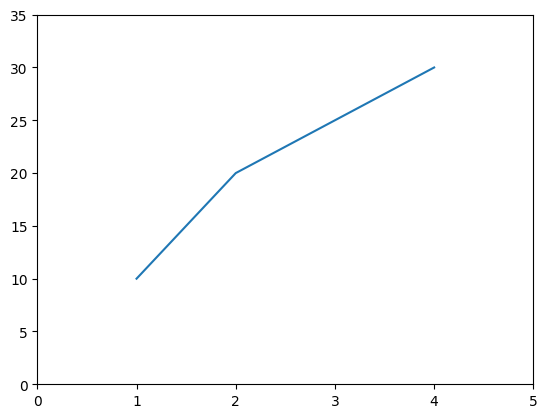

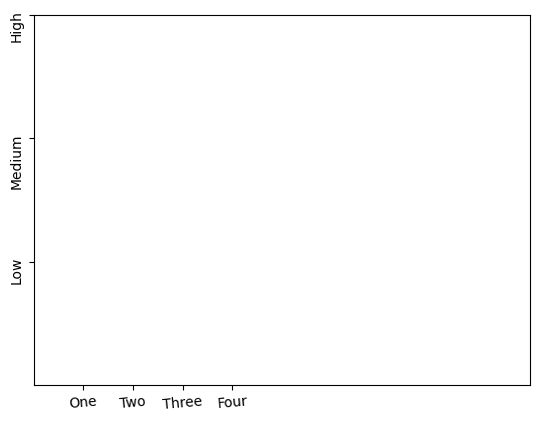

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1,2,3,4], [10,20,25,30])
plt.xlim(0, 5)
plt.ylim(0, 35)

fig, ax = plt.subplots()
ax.set_xlim(0, 10)
ax.get_xlim()

plt.xticks([1,2,3,4], ['One','Two','Three','Four'])
plt.yticks([10,20,30], ['Low','Medium','High'])
plt.xticks(rotation=45)
plt.yticks(rotation=90)

plt.show()